# GA–WaOA–LSTM Stock Forecasting

**Corrected and fast-by-default implementation** based on the GA–WOA–LSTM paper, with the Whale Optimization Algorithm replaced by the Walrus Optimization Algorithm (WaOA).

Main corrections in this notebook:

- Only **GA–WaOA–LSTM** runs by default; baseline, GA-only, and WaOA-only experiments are optional flags.
- Candidate fitness uses chronological validation data and monitors `val_loss`.
- Candidate and final training use consistent epoch/patience settings for each experiment mode.
- Every candidate is evaluated with the same fixed seed, making cached fitness values reproducible.
- Hyperparameters are optimized in a normalized search space; learning rate is decoded on a logarithmic scale.
- GA uses tournament selection, simulated binary crossover (SBX), Gaussian mutation, and elitism.
- The hybrid uses a dynamic GA/WaOA allocation: early generations emphasize GA exploration, while later generations emphasize WaOA local exploitation.
- Test windows can use the final training observations as historical context, without fitting scalers on test data.

> Default mode is `fast`. Switch to `full` only for the final paper-style experiment because it is computationally expensive.

## Imports and configuration

In [28]:
import gc
import json
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import callbacks, layers, models, optimizers

warnings.filterwarnings("ignore")

SEED = 42


def set_global_seed(seed=SEED):
    """Reset Python, NumPy, and TensorFlow RNGs for reproducible model comparisons."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


set_global_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Correct project paths when the notebook is stored in a notebooks/ folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

for directory in [DATA_DIR, OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Paper data settings
LOOKBACK = 8
FEATURE_COLUMNS = ["Open", "High", "Low", "Close", "Volume"]
TARGET_COLUMN = "Close"
TRAIN_RATIO = 0.80
VALIDATION_RATIO = 0.10

START_DATE = "2010-03-13"
END_DATE = "2025-03-13"

TICKERS = {
    "VV": "600300.SS",
    "LH": "600186.SS",
    "SY": "600429.SS",
}
RUN_STOCKS = ["VV", "LH", "SY"]

# ------------------------------------------------------------------
# Speed controls
# ------------------------------------------------------------------
# The requested fast workflow runs only the proposed hybrid model.
RUN_BASELINE_LSTM = False
RUN_GA_LSTM = False
RUN_WAOA_LSTM = False
RUN_GA_WAOA_LSTM = True

# "fast"   : code/debug runs
# "middle" : stronger development experiment
# "full"   : paper-like population/generation/final-training settings
EXPERIMENT_MODE = "full"

if EXPERIMENT_MODE == "fast":
    POP_SIZE = 4
    MAX_ITER = 3
    FITNESS_EPOCHS = 25
    FITNESS_PATIENCE = 5
    FINAL_EPOCHS = 25
    FINAL_PATIENCE = 5
elif EXPERIMENT_MODE == "middle":
    POP_SIZE = 8
    MAX_ITER = 8
    FITNESS_EPOCHS = 60
    FITNESS_PATIENCE = 10
    FINAL_EPOCHS = 60
    FINAL_PATIENCE = 10
elif EXPERIMENT_MODE == "full":
    POP_SIZE = 20
    MAX_ITER = 15
    FITNESS_EPOCHS = 80
    FITNESS_PATIENCE = 15
    FINAL_EPOCHS = 80
    FINAL_PATIENCE = 15
else:
    raise ValueError("EXPERIMENT_MODE must be 'fast', 'middle', or 'full'.")

# One fixed seed is fast and deterministic. Add seeds such as (42, 123, 2025)
# to average candidate fitness over repeated initializations.
OBJECTIVE_SEEDS = (SEED,)
OBJECTIVE_METRIC = "rmse"  # mse, rmse, or mae on the scaled validation target

# GA settings, matching the paper's stated operators more closely.
TOURNAMENT_SIZE = 3
CROSSOVER_RATE = 0.90
SBX_ETA = 15.0
GA_MUTATION_RATE_RANGE = (0.10, 0.50)
GA_MUTATION_SCALE = 0.08
ELITE_COUNT = 1

# Progressive transition from GA global exploration to WaOA exploitation.
GA_RATIO_START = 0.80
GA_RATIO_END = 0.20

print("TensorFlow:", tf.__version__)
print("Project root:", PROJECT_ROOT)
print("Experiment mode:", EXPERIMENT_MODE)
print("Stocks:", RUN_STOCKS)
print("Population / iterations:", POP_SIZE, "/", MAX_ITER)
print("Fitness epochs / patience:", FITNESS_EPOCHS, "/", FITNESS_PATIENCE)
print("Final epochs / patience:", FINAL_EPOCHS, "/", FINAL_PATIENCE)
print("Objective seeds:", OBJECTIVE_SEEDS)
print(
    "Enabled models:",
    {
        "Baseline-LSTM": RUN_BASELINE_LSTM,
        "GA-LSTM": RUN_GA_LSTM,
        "WaOA-LSTM": RUN_WAOA_LSTM,
        "GA-WaOA-LSTM": RUN_GA_WAOA_LSTM,
    },
)

TensorFlow: 2.20.0
Project root: /kaggle/working
Experiment mode: full
Stocks: ['VV', 'LH', 'SY']
Population / iterations: 20 / 15
Fitness epochs / patience: 80 / 15
Final epochs / patience: 80 / 15
Objective seeds: (42,)
Enabled models: {'Baseline-LSTM': False, 'GA-LSTM': False, 'WaOA-LSTM': False, 'GA-WaOA-LSTM': True}


## Download or load the datasets

In [29]:
def download_stock_data(symbol, name):
    csv_path = DATA_DIR / f"{name}_{symbol}.csv"

    if csv_path.exists():
        print(f"Loading cached data: {csv_path}")
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    else:
        print(f"Downloading {name}: {symbol}")
        df = yf.download(
            symbol,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=False,
            progress=False,
        )

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        if df.empty:
            raise ValueError(
                f"No data downloaded for {name} / {symbol}. "
                "Check the ticker or provide the cached CSV file."
            )

        df.to_csv(csv_path)
        print(f"Saved: {csv_path}")

    missing_columns = [column for column in FEATURE_COLUMNS if column not in df.columns]
    if missing_columns:
        raise ValueError(f"{name} is missing columns: {missing_columns}")

    df = df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").dropna()
    df = df[~df.index.duplicated(keep="first")].sort_index()
    return df


stock_data = {}
for name in RUN_STOCKS:
    symbol = TICKERS[name]
    df = download_stock_data(symbol, name)
    stock_data[name] = df

    print("=" * 70)
    print(f"{name} / {symbol}")
    print("Shape:", df.shape)
    print("Start:", df.index.min())
    print("End:", df.index.max())
    display(df.head())

Loading cached data: /kaggle/working/data/VV_600300.SS.csv
VV / 600300.SS
Shape: (3641, 5)
Start: 2010-03-15 00:00:00
End: 2025-03-12 00:00:00


,Open,High,Low,Close,Volume
Date,,,,,
2010-03-15,7.54,7.56,7.30,7.34,10584532
2010-03-16,7.34,7.39,7.30,7.38,6626677
2010-03-17,7.38,7.55,7.38,7.55,10636735
2010-03-18,7.55,7.59,7.48,7.50,8711146
2010-03-19,7.49,7.55,7.43,7.55,9717640


Loading cached data: /kaggle/working/data/LH_600186.SS.csv
LH / 600186.SS
Shape: (3641, 5)
Start: 2010-03-15 00:00:00
End: 2025-03-12 00:00:00


,Open,High,Low,Close,Volume
Date,,,,,
2010-03-15,6.60,6.70,6.48,6.67,26022391
2010-03-16,6.61,6.90,6.61,6.74,27509550
2010-03-17,6.76,7.20,6.66,7.07,71824003
2010-03-18,7.03,7.10,6.91,7.01,48727846
2010-03-19,7.03,7.14,6.92,7.07,44382278


Loading cached data: /kaggle/working/data/SY_600429.SS.csv
SY / 600429.SS
Shape: (3641, 5)
Start: 2010-03-15 00:00:00
End: 2025-03-12 00:00:00


,Open,High,Low,Close,Volume
Date,,,,,
2010-03-15,6.93,6.97,6.85,6.93,2971399
2010-03-16,6.95,6.99,6.89,6.97,2242487
2010-03-17,6.97,7.10,6.94,7.10,4189599
2010-03-18,7.08,7.29,7.07,7.28,11017834
2010-03-19,7.27,7.46,7.21,7.44,18461990


## Plot closing prices

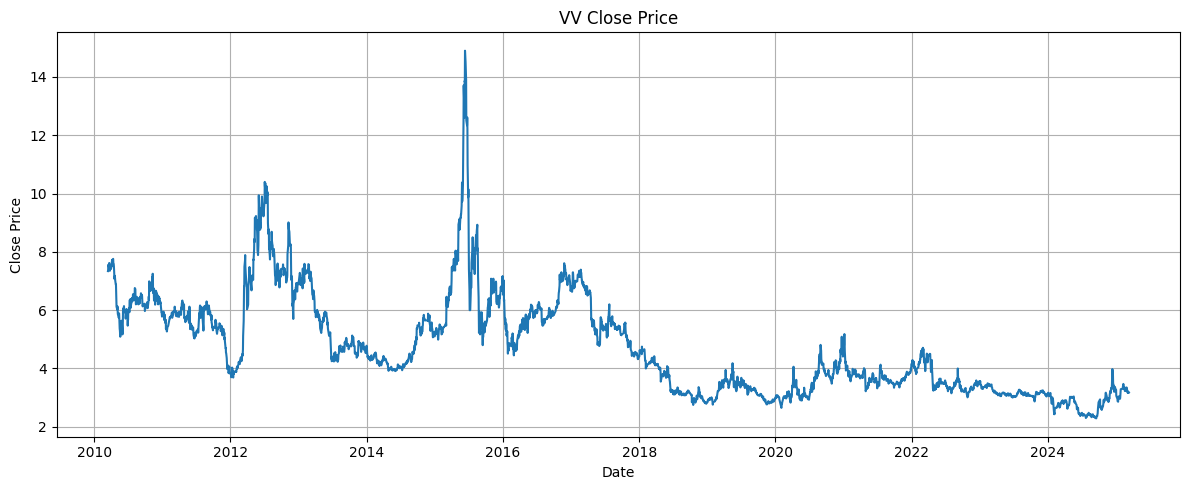

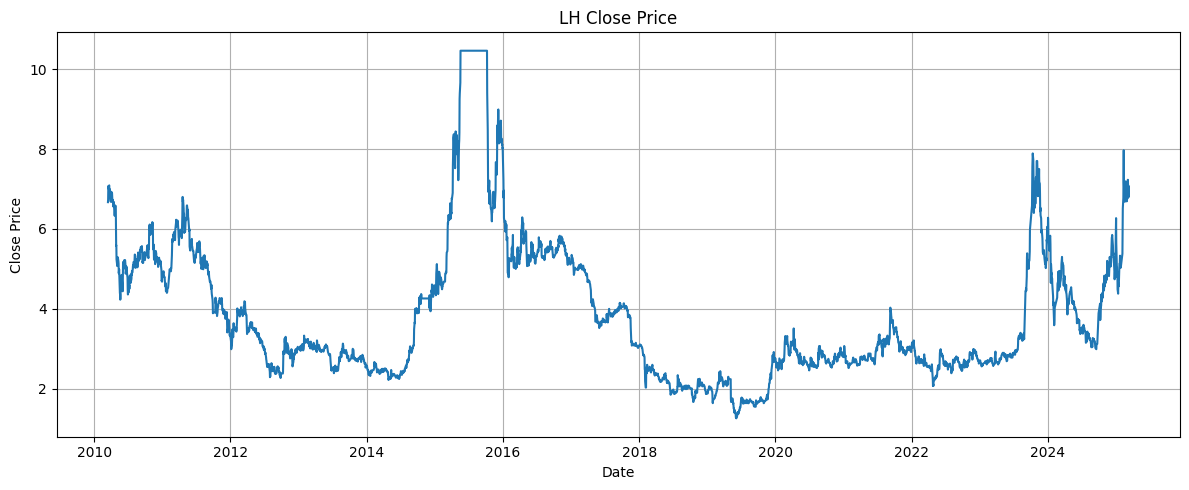

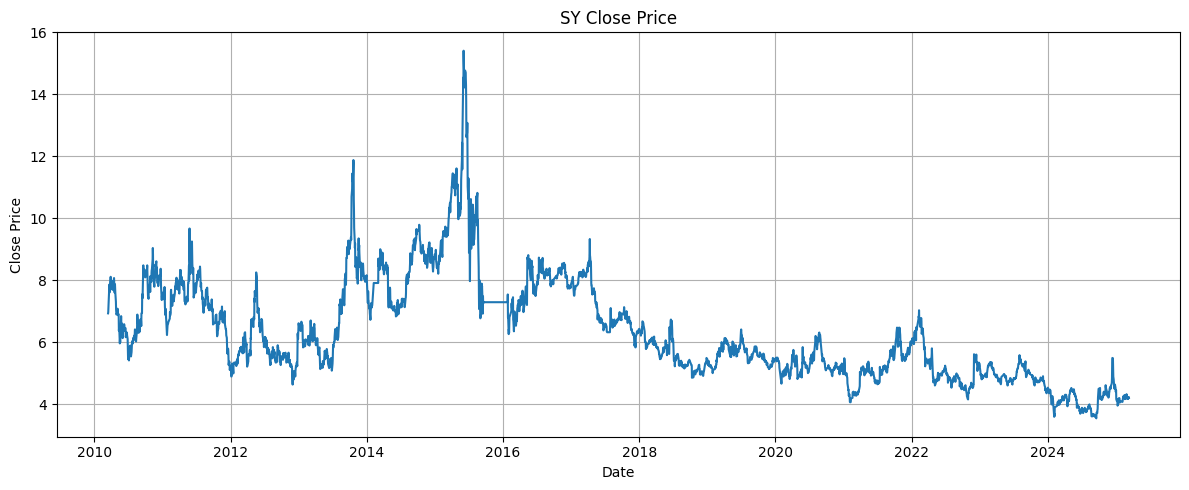

In [30]:
for name, df in stock_data.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df[TARGET_COLUMN])
    plt.title(f"{name} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Leakage-safe preprocessing with an 8-day window

In [31]:
def create_sequences(features_scaled, target_scaled, dates, lookback):
    X, y, target_indices, target_dates = [], [], [], []

    for target_idx in range(lookback, len(features_scaled)):
        X.append(features_scaled[target_idx - lookback : target_idx])
        y.append(target_scaled[target_idx])
        target_indices.append(target_idx)
        target_dates.append(dates[target_idx])

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(target_indices),
        pd.DatetimeIndex(target_dates),
    )


def prepare_data(df, lookback=LOOKBACK, train_ratio=TRAIN_RATIO):
    """
    Fit scalers only on the first 80% of raw observations, transform the full
    series, and then create windows. The first test target can therefore use
    the final training observations as historical context without leakage.
    """
    split_idx = int(len(df) * train_ratio)
    if split_idx <= lookback or split_idx >= len(df):
        raise ValueError("The dataset is too short for the requested split/lookback.")

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    feature_scaler.fit(train_df[FEATURE_COLUMNS])
    target_scaler.fit(train_df[[TARGET_COLUMN]])

    all_features_scaled = feature_scaler.transform(df[FEATURE_COLUMNS])
    all_target_scaled = target_scaler.transform(df[[TARGET_COLUMN]])

    X_all, y_all, target_indices, target_dates = create_sequences(
        all_features_scaled,
        all_target_scaled,
        df.index,
        lookback,
    )

    train_mask = target_indices < split_idx
    test_mask = ~train_mask

    return {
        "X_train": X_all[train_mask],
        "y_train": y_all[train_mask],
        "X_test": X_all[test_mask],
        "y_test": y_all[test_mask],
        "train_dates": target_dates[train_mask],
        "test_dates": target_dates[test_mask],
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "train_df": train_df,
        "test_df": test_df,
        "raw_split_idx": split_idx,
    }


prepared = {}
for name, df in stock_data.items():
    prepared[name] = prepare_data(df)
    print(name)
    print("X_train:", prepared[name]["X_train"].shape)
    print("y_train:", prepared[name]["y_train"].shape)
    print("X_test :", prepared[name]["X_test"].shape)
    print("y_test :", prepared[name]["y_test"].shape)

VV
X_train: (2904, 8, 5)
y_train: (2904, 1)
X_test : (729, 8, 5)
y_test : (729, 1)
LH
X_train: (2904, 8, 5)
y_train: (2904, 1)
X_test : (729, 8, 5)
y_test : (729, 1)
SY
X_train: (2904, 8, 5)
y_train: (2904, 1)
X_test : (729, 8, 5)
y_test : (729, 1)


## Metrics and LSTM model

In [32]:
def build_lstm_model(input_shape, units, dropout, learning_rate):
    model = models.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.LSTM(int(units)),
            layers.Dropout(float(dropout)),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=float(learning_rate)),
        loss="mse",
    )
    return model


def regression_metrics(y_true_raw, y_pred_raw):
    y_true_raw = np.asarray(y_true_raw).reshape(-1)
    y_pred_raw = np.asarray(y_pred_raw).reshape(-1)

    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))

    denominator = np.where(np.abs(y_true_raw) < 1e-8, 1e-8, y_true_raw)
    mape = np.mean(np.abs((y_true_raw - y_pred_raw) / denominator)) * 100.0
    r2 = r2_score(y_true_raw, y_pred_raw)

    return {"MAE": mae, "MAPE": mape, "RMSE": rmse, "R2": r2}


def inverse_target(y_scaled, target_scaler):
    return target_scaler.inverse_transform(
        np.asarray(y_scaled).reshape(-1, 1)
    ).reshape(-1)


def chronological_validation_split(X, y, validation_ratio=VALIDATION_RATIO):
    split_idx = int(len(X) * (1.0 - validation_ratio))
    if split_idx <= 0 or split_idx >= len(X):
        raise ValueError("Invalid chronological validation split.")
    return X[:split_idx], y[:split_idx], X[split_idx:], y[split_idx:]


def make_callbacks(patience):
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            mode="min",
        ),
        callbacks.TerminateOnNaN(),
    ]

## Normalized hyperparameter representation

In [33]:
# Optimization occurs in a centered normalized space. This prevents variables
# such as units from dominating variables such as dropout or learning rate.
SEARCH_BOUNDS = np.array([[-1.0, 1.0]] * 4, dtype=float)
PARAM_NAMES = ["units", "dropout", "batch_size", "log10_learning_rate"]

PARAM_RANGES = {
    "units": (256, 512),
    "dropout": (0.05, 0.15),
    "batch_size": (16, 128),
    "log10_learning_rate": (-4.0, -2.0),
}


def clip_position(position):
    position = np.asarray(position, dtype=float)
    return np.clip(position, SEARCH_BOUNDS[:, 0], SEARCH_BOUNDS[:, 1])


def position_to_unit_interval(position):
    position = clip_position(position)
    return (position - SEARCH_BOUNDS[:, 0]) / (
        SEARCH_BOUNDS[:, 1] - SEARCH_BOUNDS[:, 0]
    )


def decode_position(position):
    u = position_to_unit_interval(position)

    units_low, units_high = PARAM_RANGES["units"]
    dropout_low, dropout_high = PARAM_RANGES["dropout"]
    batch_low, batch_high = PARAM_RANGES["batch_size"]
    log_lr_low, log_lr_high = PARAM_RANGES["log10_learning_rate"]

    units = int(round(units_low + u[0] * (units_high - units_low)))
    dropout = float(dropout_low + u[1] * (dropout_high - dropout_low))
    batch_size = int(round(batch_low + u[2] * (batch_high - batch_low)))
    log10_learning_rate = float(log_lr_low + u[3] * (log_lr_high - log_lr_low))
    learning_rate = float(10.0 ** log10_learning_rate)

    return {
        "units": int(np.clip(units, units_low, units_high)),
        "dropout": float(np.clip(dropout, dropout_low, dropout_high)),
        "batch_size": int(np.clip(batch_size, batch_low, batch_high)),
        "learning_rate": learning_rate,
        "log10_learning_rate": log10_learning_rate,
    }


def encode_parameters(units, dropout, batch_size, learning_rate):
    values = np.array(
        [
            units,
            dropout,
            batch_size,
            np.log10(learning_rate),
        ],
        dtype=float,
    )
    lows = np.array(
        [
            PARAM_RANGES["units"][0],
            PARAM_RANGES["dropout"][0],
            PARAM_RANGES["batch_size"][0],
            PARAM_RANGES["log10_learning_rate"][0],
        ]
    )
    highs = np.array(
        [
            PARAM_RANGES["units"][1],
            PARAM_RANGES["dropout"][1],
            PARAM_RANGES["batch_size"][1],
            PARAM_RANGES["log10_learning_rate"][1],
        ]
    )
    unit_values = (values - lows) / (highs - lows)
    return clip_position(SEARCH_BOUNDS[:, 0] + unit_values * (SEARCH_BOUNDS[:, 1] - SEARCH_BOUNDS[:, 0]))


def print_params(title, position):
    params = decode_position(position)
    print(title)
    for key in ["units", "dropout", "batch_size", "learning_rate"]:
        print(f"  {key}: {params[key]}")

## Reproducible chronological fitness function

In [34]:
class LSTMObjective:
    """Deterministic validation objective for LSTM hyperparameter search."""

    def __init__(self, X_train, y_train, input_shape):
        self.input_shape = input_shape
        self.X_fit, self.y_fit, self.X_val, self.y_val = chronological_validation_split(
            X_train,
            y_train,
            VALIDATION_RATIO,
        )
        self.cache = {}
        self.evaluation_count = 0

    @staticmethod
    def _cache_key(params):
        return (
            params["units"],
            round(params["dropout"], 5),
            params["batch_size"],
            round(params["log10_learning_rate"], 6),
        )

    def _evaluate_seed(self, params, seed):
        tf.keras.backend.clear_session()
        gc.collect()
        set_global_seed(seed)

        model = build_lstm_model(
            input_shape=self.input_shape,
            units=params["units"],
            dropout=params["dropout"],
            learning_rate=params["learning_rate"],
        )

        model.fit(
            self.X_fit,
            self.y_fit,
            validation_data=(self.X_val, self.y_val),
            epochs=FITNESS_EPOCHS,
            batch_size=params["batch_size"],
            shuffle=False,
            verbose=0,
            callbacks=make_callbacks(FITNESS_PATIENCE),
        )

        pred_val = model.predict(self.X_val, verbose=0).reshape(-1)
        y_val = self.y_val.reshape(-1)

        if OBJECTIVE_METRIC == "mse":
            score = mean_squared_error(y_val, pred_val)
        elif OBJECTIVE_METRIC == "rmse":
            score = np.sqrt(mean_squared_error(y_val, pred_val))
        elif OBJECTIVE_METRIC == "mae":
            score = mean_absolute_error(y_val, pred_val)
        else:
            raise ValueError("OBJECTIVE_METRIC must be 'mse', 'rmse', or 'mae'.")

        del model
        tf.keras.backend.clear_session()
        gc.collect()
        return float(score)

    def __call__(self, position):
        params = decode_position(position)
        key = self._cache_key(params)

        if key in self.cache:
            return self.cache[key]

        scores = [self._evaluate_seed(params, seed) for seed in OBJECTIVE_SEEDS]
        score = float(np.mean(scores))

        if not np.isfinite(score):
            score = 1e9

        self.cache[key] = score
        self.evaluation_count += 1
        return score

## Walrus Optimization Algorithm (WaOA) operators

In [35]:
def initialize_population(pop_size):
    low = SEARCH_BOUNDS[:, 0]
    high = SEARCH_BOUNDS[:, 1]
    return low + np.random.rand(pop_size, len(low)) * (high - low)


def evaluate_population(population, objective):
    return np.asarray([objective(individual) for individual in population], dtype=float)


def waoa_phase_1(population, fitness, objective):
    """Feeding under the strongest walrus: global exploration."""
    population = population.copy()
    fitness = fitness.copy()
    best_position = population[np.argmin(fitness)].copy()
    dimensions = population.shape[1]

    for i in range(len(population)):
        rand = np.random.rand(dimensions)
        I = np.random.randint(1, 3, size=dimensions)
        candidate = population[i] + rand * (best_position - I * population[i])
        candidate = clip_position(candidate)
        candidate_score = objective(candidate)

        if candidate_score < fitness[i]:
            population[i] = candidate
            fitness[i] = candidate_score

    return population, fitness


def waoa_phase_2(population, fitness, objective):
    """Migration toward another randomly selected walrus."""
    population = population.copy()
    fitness = fitness.copy()
    dimensions = population.shape[1]

    for i in range(len(population)):
        choices = np.delete(np.arange(len(population)), i)
        k = int(np.random.choice(choices))
        rand = np.random.rand(dimensions)
        I = np.random.randint(1, 3, size=dimensions)

        if fitness[k] < fitness[i]:
            candidate = population[i] + rand * (population[k] - I * population[i])
        else:
            candidate = population[i] + rand * (population[i] - population[k])

        candidate = clip_position(candidate)
        candidate_score = objective(candidate)

        if candidate_score < fitness[i]:
            population[i] = candidate
            fitness[i] = candidate_score

    return population, fitness


def waoa_phase_3(population, fitness, objective, iteration_number):
    """
    Predator escape/fight phase: local exploitation using the published
    shrinking local bounds, without the previous extra sign and multiplier.
    """
    population = population.copy()
    fitness = fitness.copy()
    t = max(1, int(iteration_number))
    dimensions = population.shape[1]

    local_lower = SEARCH_BOUNDS[:, 0] / t
    local_upper = SEARCH_BOUNDS[:, 1] / t

    for i in range(len(population)):
        rand = np.random.rand(dimensions)
        local_step = local_lower + (local_upper - rand * local_lower)
        candidate = clip_position(population[i] + local_step)
        candidate_score = objective(candidate)

        if candidate_score < fitness[i]:
            population[i] = candidate
            fitness[i] = candidate_score

    return population, fitness


def waoa_optimize(objective, pop_size=POP_SIZE, max_iter=MAX_ITER):
    """Standalone WaOA, retained for optional final ablation experiments."""
    population = initialize_population(pop_size)
    fitness = evaluate_population(population, objective)
    history = {"best_score": []}

    for iteration in tqdm(range(1, max_iter + 1), desc="WaOA"):
        population, fitness = waoa_phase_1(population, fitness, objective)
        population, fitness = waoa_phase_2(population, fitness, objective)
        population, fitness = waoa_phase_3(
            population,
            fitness,
            objective,
            iteration_number=iteration,
        )

        best_idx = int(np.argmin(fitness))
        history["best_score"].append(float(fitness[best_idx]))
        print(
            f"Iter {iteration}/{max_iter} | Best: {fitness[best_idx]:.6f} | "
            f"{decode_position(population[best_idx])}"
        )

    best_idx = int(np.argmin(fitness))
    return population[best_idx].copy(), float(fitness[best_idx]), history

## Genetic Algorithm operators

In [36]:
def tournament_selection(population, fitness, tournament_size=TOURNAMENT_SIZE):
    indices = np.random.choice(len(population), tournament_size, replace=True)
    winner = indices[np.argmin(fitness[indices])]
    return population[winner].copy()


def simulated_binary_crossover(parent1, parent2, crossover_rate=CROSSOVER_RATE, eta=SBX_ETA):
    """Real-valued SBX crossover followed by bound clipping."""
    if np.random.rand() > crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = parent1.copy()
    child2 = parent2.copy()

    for j in range(len(parent1)):
        if np.random.rand() <= 0.5 and abs(parent1[j] - parent2[j]) > 1e-12:
            u = np.random.rand()
            if u <= 0.5:
                beta = (2.0 * u) ** (1.0 / (eta + 1.0))
            else:
                beta = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta + 1.0))

            child1[j] = 0.5 * ((1.0 + beta) * parent1[j] + (1.0 - beta) * parent2[j])
            child2[j] = 0.5 * ((1.0 - beta) * parent1[j] + (1.0 + beta) * parent2[j])

    return clip_position(child1), clip_position(child2)


def gaussian_mutation(individual, mutation_rate, mutation_scale=GA_MUTATION_SCALE):
    child = individual.copy()
    search_width = SEARCH_BOUNDS[:, 1] - SEARCH_BOUNDS[:, 0]

    mutation_mask = np.random.rand(len(child)) < mutation_rate
    if np.any(mutation_mask):
        child[mutation_mask] += np.random.normal(
            loc=0.0,
            scale=mutation_scale * search_width[mutation_mask],
        )

    return clip_position(child)


def generate_ga_offspring(population, fitness, n_offspring, mutation_rate):
    offspring = []

    while len(offspring) < n_offspring:
        parent1 = tournament_selection(population, fitness)
        parent2 = tournament_selection(population, fitness)
        child1, child2 = simulated_binary_crossover(parent1, parent2)
        child1 = gaussian_mutation(child1, mutation_rate)
        child2 = gaussian_mutation(child2, mutation_rate)

        offspring.append(child1)
        if len(offspring) < n_offspring:
            offspring.append(child2)

    return np.asarray(offspring)


def select_best(population, fitness, n_keep):
    best_indices = np.argsort(fitness)[:n_keep]
    return population[best_indices].copy(), fitness[best_indices].copy()


def ga_optimize(objective, pop_size=POP_SIZE, max_iter=MAX_ITER):
    """Standalone GA, retained but disabled by default."""
    population = initialize_population(pop_size)
    fitness = evaluate_population(population, objective)
    history = {"best_score": []}

    for generation in tqdm(range(1, max_iter + 1), desc="GA"):
        mutation_rate = np.random.uniform(*GA_MUTATION_RATE_RANGE)
        offspring = generate_ga_offspring(
            population,
            fitness,
            n_offspring=pop_size,
            mutation_rate=mutation_rate,
        )
        offspring_fitness = evaluate_population(offspring, objective)

        combined_population = np.vstack([population, offspring])
        combined_fitness = np.concatenate([fitness, offspring_fitness])
        population, fitness = select_best(combined_population, combined_fitness, pop_size)

        history["best_score"].append(float(fitness[0]))
        print(
            f"Gen {generation}/{max_iter} | Best: {fitness[0]:.6f} | "
            f"{decode_position(population[0])}"
        )

    return population[0].copy(), float(fitness[0]), history

## Dynamic GA–WaOA hybrid optimizer

In [37]:
def progressive_ga_ratio(generation, max_iter):
    if max_iter <= 1:
        return GA_RATIO_END
    progress = (generation - 1) / (max_iter - 1)
    return GA_RATIO_START + progress * (GA_RATIO_END - GA_RATIO_START)


def ga_waoa_optimize(objective, pop_size=POP_SIZE, max_iter=MAX_ITER):
    """
    Hybrid search with a progressive allocation:

    - Early generations: more GA offspring for global exploration.
    - Later generations: more elite candidates receive WaOA phase-3 refinement.
    - Parents, GA offspring, and WaOA-refined candidates compete under elitist
      survivor selection, so the best solution cannot be lost.
    """
    population = initialize_population(pop_size)
    fitness = evaluate_population(population, objective)

    history = {
        "best_score": [],
        "ga_ratio": [],
        "waoa_ratio": [],
        "mutation_rate": [],
    }

    for generation in tqdm(range(1, max_iter + 1), desc="GA-WaOA"):
        ga_ratio = progressive_ga_ratio(generation, max_iter)
        ga_count = int(round(pop_size * ga_ratio))
        ga_count = min(pop_size - 1, max(1, ga_count))
        waoa_count = pop_size - ga_count

        mutation_rate = float(np.random.uniform(*GA_MUTATION_RATE_RANGE))

        # GA explores globally using the current full population as parents.
        ga_offspring = generate_ga_offspring(
            population,
            fitness,
            n_offspring=ga_count,
            mutation_rate=mutation_rate,
        )
        ga_fitness = evaluate_population(ga_offspring, objective)

        # Select the strongest available candidates as WaOA local-search seeds.
        pre_refine_population = np.vstack([population, ga_offspring])
        pre_refine_fitness = np.concatenate([fitness, ga_fitness])
        waoa_seeds, waoa_seed_fitness = select_best(
            pre_refine_population,
            pre_refine_fitness,
            n_keep=waoa_count,
        )

        # Only the exploitation phase is used in the hybrid refinement stage.
        waoa_refined, waoa_refined_fitness = waoa_phase_3(
            waoa_seeds,
            waoa_seed_fitness,
            objective,
            iteration_number=generation,
        )

        # Elitist survivor selection from parents, GA offspring, and WaOA output.
        combined_population = np.vstack(
            [population, ga_offspring, waoa_refined]
        )
        combined_fitness = np.concatenate(
            [fitness, ga_fitness, waoa_refined_fitness]
        )
        population, fitness = select_best(
            combined_population,
            combined_fitness,
            n_keep=pop_size,
        )

        best_score = float(fitness[0])
        history["best_score"].append(best_score)
        history["ga_ratio"].append(float(ga_count / pop_size))
        history["waoa_ratio"].append(float(waoa_count / pop_size))
        history["mutation_rate"].append(mutation_rate)

        print(
            f"Gen {generation}/{max_iter} | Best: {best_score:.6f} | "
            f"GA/WaOA: {ga_count}/{waoa_count} | "
            f"{decode_position(population[0])}"
        )

    return population[0].copy(), float(fitness[0]), history

## Train and evaluate the selected final model

In [38]:
def train_final_model(data_dict, best_position, model_name, stock_name, seed=SEED):
    params = decode_position(best_position)

    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    X_test = data_dict["X_test"]
    y_test = data_dict["y_test"]
    target_scaler = data_dict["target_scaler"]

    X_fit, y_fit, X_val, y_val = chronological_validation_split(
        X_train,
        y_train,
        VALIDATION_RATIO,
    )

    tf.keras.backend.clear_session()
    gc.collect()
    set_global_seed(seed)

    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=params["units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"],
    )

    history = model.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val),
        epochs=FINAL_EPOCHS,
        batch_size=params["batch_size"],
        shuffle=False,
        verbose=1,
        callbacks=make_callbacks(FINAL_PATIENCE),
    )

    pred_train_scaled = model.predict(X_train, verbose=0)
    pred_test_scaled = model.predict(X_test, verbose=0)

    y_train_raw = inverse_target(y_train, target_scaler)
    y_test_raw = inverse_target(y_test, target_scaler)
    pred_train_raw = inverse_target(pred_train_scaled, target_scaler)
    pred_test_raw = inverse_target(pred_test_scaled, target_scaler)

    train_metrics = regression_metrics(y_train_raw, pred_train_raw)
    test_metrics = regression_metrics(y_test_raw, pred_test_raw)

    save_path = MODEL_DIR / f"{stock_name}_{model_name}_{EXPERIMENT_MODE}.keras"
    model.save(save_path)

    validation_losses = history.history.get("val_loss", [])
    best_epoch = int(np.argmin(validation_losses) + 1) if validation_losses else len(history.history["loss"])

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "params": params,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "y_train_raw": y_train_raw,
        "y_test_raw": y_test_raw,
        "pred_train_raw": pred_train_raw,
        "pred_test_raw": pred_test_raw,
        "model_path": save_path,
    }

## Run enabled experiments

Running stock dataset: VV


2026-07-21 06:28:42.899586: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 06:29:01.877327: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

GA-WaOA:   0%|          | 0/15 [00:00<?, ?it/s]

2026-07-21 06:36:49.151223: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-21 06:37:16.959426: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Gen 1/15 | Best: 0.008164 | GA/WaOA: 16/4 | {'units': 400, 'dropout': 0.15, 'batch_size': 128, 'learning_rate': 0.005648424224848597, 'log10_learning_rate': -2.248072693048313}


...

Gen 15/15 | Best: 0.007624 | GA/WaOA: 4/16 | {'units': 305, 'dropout': 0.15, 'batch_size': 123, 'learning_rate': 0.005984376611904891, 'log10_learning_rate': -2.222981083037083}
Best GA-WaOA-LSTM parameters
  units: 305
  dropout: 0.15
  batch_size: 123
  learning_rate: 0.005984376611904891
Epoch 1/80


2026-07-21 07:29:35.135537: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0335 - val_loss: 0.0027
Epoch 2/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0046 - val_loss: 6.3913e-04
Epoch 3/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0021 - val_loss: 1.8996e-04
Epoch 4/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 2.6615e-04
Epoch 5/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 2.4279e-04
Epoch 6/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.3283e-04 - val_loss: 2.3461e-04
Epoch 7/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.0767e-04 - val_loss: 1.6265e-04
Epoch 8/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.9908e-04 - val_loss: 1.2044e-04
Epoch 9/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.6092e-04 - val_loss: 2.3099e-04
Epoch 10/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.8603e-04 - val_loss: 2.2024e-04
Epoch 11/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.2983e-04 - val_loss: 2.1610e-04
Epoch 12/8

2026-07-21 07:29:55.613798: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Unique candidate evaluations for VV: 194


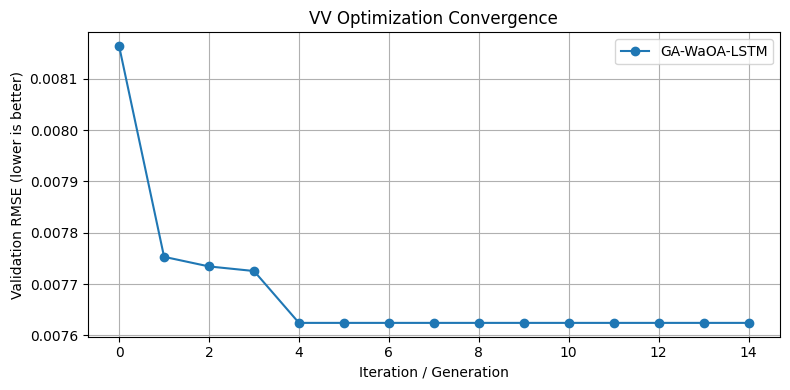

Saved convergence figure: /kaggle/working/figures/VV_convergence_full.png
Running stock dataset: LH


2026-07-21 07:30:00.968589: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 07:30:16.727817: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

GA-WaOA:   0%|          | 0/15 [00:00<?, ?it/s]

2026-07-21 07:37:44.901281: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 07:38:38.532265: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Gen 1/15 | Best: 0.008441 | GA/WaOA: 16/4 | {'units': 256, 'dropout': 0.06959828624191453, 'batch_size': 21, 'learning_rate': 0.00044736361746212656, 'log10_learning_rate': -3.349339338473471}


...

Gen 15/15 | Best: 0.008196 | GA/WaOA: 4/16 | {'units': 257, 'dropout': 0.06082815987966368, 'batch_size': 16, 'learning_rate': 0.0005639887633049089, 'log10_learning_rate': -3.2487295486465984}
Best GA-WaOA-LSTM parameters
  units: 257
  dropout: 0.06082815987966368
  batch_size: 16
  learning_rate: 0.0005639887633049089
Epoch 1/80


2026-07-21 10:39:49.349762: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0052 - val_loss: 2.2926e-04
Epoch 2/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0024 - val_loss: 2.0750e-04
Epoch 3/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0046 - val_loss: 4.7400e-04
Epoch 4/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0055 - val_loss: 3.5297e-04
Epoch 5/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - val_loss: 2.0264e-04
Epoch 6/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - val_loss: 1.7082e-04
Epoch 7/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0017 - val_loss: 1.3773e-04
Epoch 8/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013 - val_loss: 1.1827e-04
Epoch 9/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012 - val_loss: 1.1258e-04
Epoch 10/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 1.0794e-04
Epoch 11/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 1.1200e-04
Epoch 12/80
164/164

2026-07-21 10:40:58.546576: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Unique candidate evaluations for LH: 204


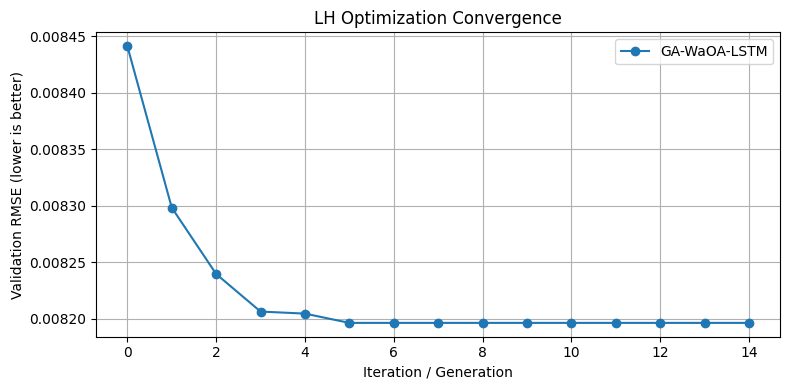

Saved convergence figure: /kaggle/working/figures/LH_convergence_full.png
Running stock dataset: SY


2026-07-21 10:41:04.564617: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 10:41:26.055039: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

GA-WaOA:   0%|          | 0/15 [00:00<?, ?it/s]

2026-07-21 10:52:45.327891: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-21 10:53:33.276435: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Gen 1/15 | Best: 0.011174 | GA/WaOA: 16/4 | {'units': 271, 'dropout': 0.1315461428454834, 'batch_size': 83, 'learning_rate': 0.004965137607642841, 'log10_learning_rate': -2.3040687106304736}


...

Gen 15/15 | Best: 0.011174 | GA/WaOA: 4/16 | {'units': 271, 'dropout': 0.1315461428454834, 'batch_size': 83, 'learning_rate': 0.004965137607642841, 'log10_learning_rate': -2.3040687106304736}
Best GA-WaOA-LSTM parameters
  units: 271
  dropout: 0.1315461428454834
  batch_size: 83
  learning_rate: 0.004965137607642841
Epoch 1/80


2026-07-21 11:59:35.045060: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0056 - val_loss: 2.5197e-04
Epoch 2/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 5.1213e-04
Epoch 3/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021 - val_loss: 2.7182e-04
Epoch 4/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.8545e-04 - val_loss: 2.0489e-04
Epoch 5/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.4786e-04 - val_loss: 1.9005e-04
Epoch 6/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.8622e-04 - val_loss: 1.8763e-04
Epoch 7/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.3399e-04 - val_loss: 1.8940e-04
Epoch 8/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.6295e-04 - val_loss: 2.0578e-04
Epoch 9/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.0352e-04 - val_loss: 3.1890e-04
Epoch 10/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.4129e-04 - val_loss: 2.1037e-04
Epoch 11/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.3772e-04 - val_loss: 2.0927e-04
Epoch 12

2026-07-21 11:59:53.905719: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Unique candidate evaluations for SY: 152


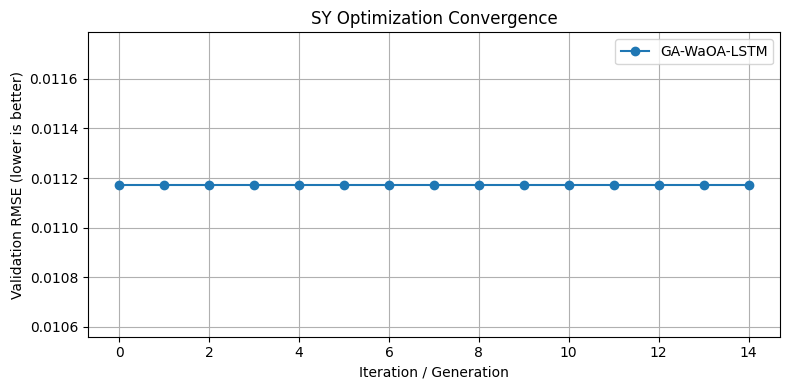

Saved convergence figure: /kaggle/working/figures/SY_convergence_full.png


In [39]:
all_results = []
all_predictions = {}
all_histories = {}


def register_result(stock_name, display_name, output, optimization_score=None):
    row = {
        "Stock": stock_name,
        "Model": display_name,
        **{f"Train_{key}": value for key, value in output["train_metrics"].items()},
        **{f"Test_{key}": value for key, value in output["test_metrics"].items()},
        "best_epoch": output["best_epoch"],
        "optimization_score": optimization_score,
        **output["params"],
    }
    all_results.append(row)
    all_predictions[(stock_name, display_name)] = output


for stock_name in RUN_STOCKS:
    data_dict = prepared[stock_name]
    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    objective = LSTMObjective(X_train, y_train, X_train.shape[1:])

    print("=" * 90)
    print(f"Running stock dataset: {stock_name}")
    print("=" * 90)

    if RUN_BASELINE_LSTM:
        baseline_position = encode_parameters(256, 0.10, 32, 0.001)
        print_params("Baseline LSTM parameters", baseline_position)
        output = train_final_model(
            data_dict,
            baseline_position,
            model_name="Baseline_LSTM",
            stock_name=stock_name,
        )
        register_result(stock_name, "Baseline-LSTM", output)

    if RUN_GA_LSTM:
        best_position, best_score, history = ga_optimize(
            objective,
            pop_size=POP_SIZE,
            max_iter=MAX_ITER,
        )
        print_params("Best GA-LSTM parameters", best_position)
        output = train_final_model(
            data_dict,
            best_position,
            model_name="GA_LSTM",
            stock_name=stock_name,
        )
        register_result(stock_name, "GA-LSTM", output, best_score)
        all_histories[(stock_name, "GA-LSTM")] = history

    if RUN_WAOA_LSTM:
        best_position, best_score, history = waoa_optimize(
            objective,
            pop_size=POP_SIZE,
            max_iter=MAX_ITER,
        )
        print_params("Best WaOA-LSTM parameters", best_position)
        output = train_final_model(
            data_dict,
            best_position,
            model_name="WaOA_LSTM",
            stock_name=stock_name,
        )
        register_result(stock_name, "WaOA-LSTM", output, best_score)
        all_histories[(stock_name, "WaOA-LSTM")] = history

    if RUN_GA_WAOA_LSTM:
        best_position, best_score, history = ga_waoa_optimize(
            objective,
            pop_size=POP_SIZE,
            max_iter=MAX_ITER,
        )
        print_params("Best GA-WaOA-LSTM parameters", best_position)
        output = train_final_model(
            data_dict,
            best_position,
            model_name="GA_WaOA_LSTM",
            stock_name=stock_name,
        )
        register_result(stock_name, "GA-WaOA-LSTM", output, best_score)
        all_histories[(stock_name, "GA-WaOA-LSTM")] = history

    print(f"Unique candidate evaluations for {stock_name}: {objective.evaluation_count}")

    stock_histories = {
        model_name: history
        for (history_stock, model_name), history in all_histories.items()
        if history_stock == stock_name
    }
    if stock_histories:
        plt.figure(figsize=(8, 4))
        for model_name, history in stock_histories.items():
            plt.plot(history["best_score"], marker="o", label=model_name)
        plt.title(f"{stock_name} Optimization Convergence")
        plt.xlabel("Iteration / Generation")
        plt.ylabel(f"Validation {OBJECTIVE_METRIC.upper()} (lower is better)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        fig_path = FIGURE_DIR / f"{stock_name}_convergence_{EXPERIMENT_MODE}.png"
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved convergence figure: {fig_path}")

## Results table and saved configuration

In [42]:
if not all_results:
    raise RuntimeError("No model is enabled. Enable at least one RUN_* flag in the configuration cell.")

results_df = pd.DataFrame(all_results).sort_values(["Stock", "Test_RMSE"])
display(results_df)

results_path = OUTPUT_DIR / f"results_metrics_{EXPERIMENT_MODE}.csv"
latest_results_path = OUTPUT_DIR / "results_metrics.csv"
results_df.to_csv(results_path, index=False)
results_df.to_csv(latest_results_path, index=False)

config = {
    "seed": SEED,
    "experiment_mode": EXPERIMENT_MODE,
    "lookback": LOOKBACK,
    "train_ratio": TRAIN_RATIO,
    "validation_ratio": VALIDATION_RATIO,
    "population_size": POP_SIZE,
    "max_iterations": MAX_ITER,
    "fitness_epochs": FITNESS_EPOCHS,
    "fitness_patience": FITNESS_PATIENCE,
    "final_epochs": FINAL_EPOCHS,
    "final_patience": FINAL_PATIENCE,
    "objective_metric": OBJECTIVE_METRIC,
    "objective_seeds": list(OBJECTIVE_SEEDS),
    "run_flags": {
        "baseline_lstm": RUN_BASELINE_LSTM,
        "ga_lstm": RUN_GA_LSTM,
        "waoa_lstm": RUN_WAOA_LSTM,
        "ga_waoa_lstm": RUN_GA_WAOA_LSTM,
    },
    "ga_ratio_start": GA_RATIO_START,
    "ga_ratio_end": GA_RATIO_END,
}
config_path = OUTPUT_DIR / f"experiment_config_{EXPERIMENT_MODE}.json"
config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")

print(f"Saved results: {results_path}")
print(f"Saved latest results: {latest_results_path}")
print(f"Saved configuration: {config_path}")

,Stock,Model,Train_MAE,Train_MAPE,Train_RMSE,Train_R2,Test_MAE,Test_MAPE,Test_RMSE,Test_R2,best_epoch,optimization_score,units,dropout,batch_size,learning_rate,log10_learning_rate
1,LH,GA-WaOA-LSTM,0.142140,3.019038,0.241471,0.983809,0.149927,3.194747,0.256283,0.965998,74,0.008196,257,0.060828,16,0.000564,-3.248730
2,SY,GA-WaOA-LSTM,0.122623,1.749871,0.192354,0.984581,0.062200,1.350058,0.091336,0.964629,50,0.011174,271,0.131546,83,0.004965,-2.304069
0,VV,GA-WaOA-LSTM,0.122394,2.174381,0.195207,0.986342,0.048654,1.545836,0.072392,0.967377,78,0.007624,305,0.150000,123,0.005984,-2.222981


Saved results: /kaggle/working/outputs/results_metrics_full.csv
Saved latest results: /kaggle/working/outputs/results_metrics.csv
Saved configuration: /kaggle/working/outputs/experiment_config_full.json


## Actual versus predicted closing prices

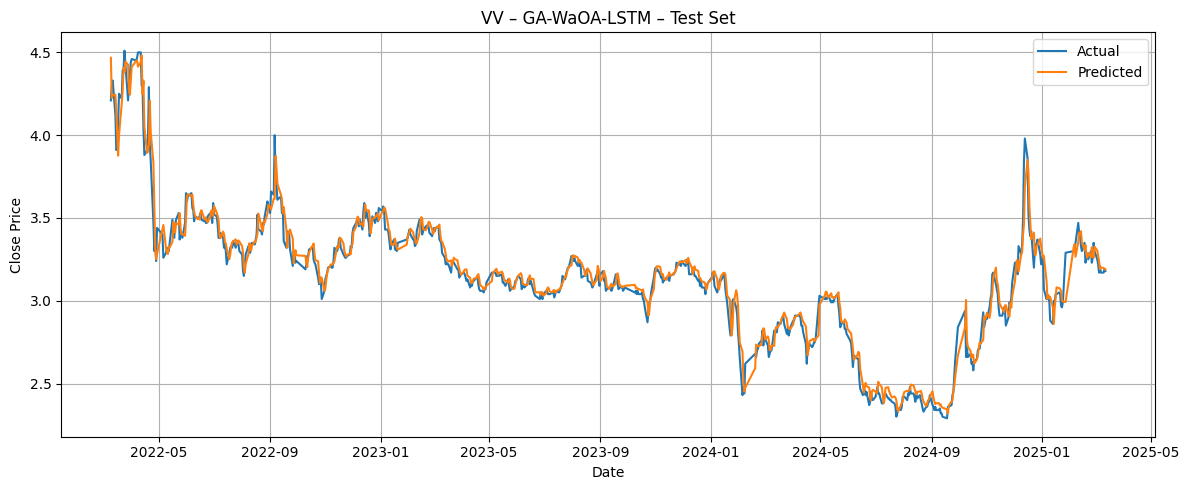

Saved figure: /kaggle/working/figures/VV_GA-WaOA-LSTM_prediction_full.png


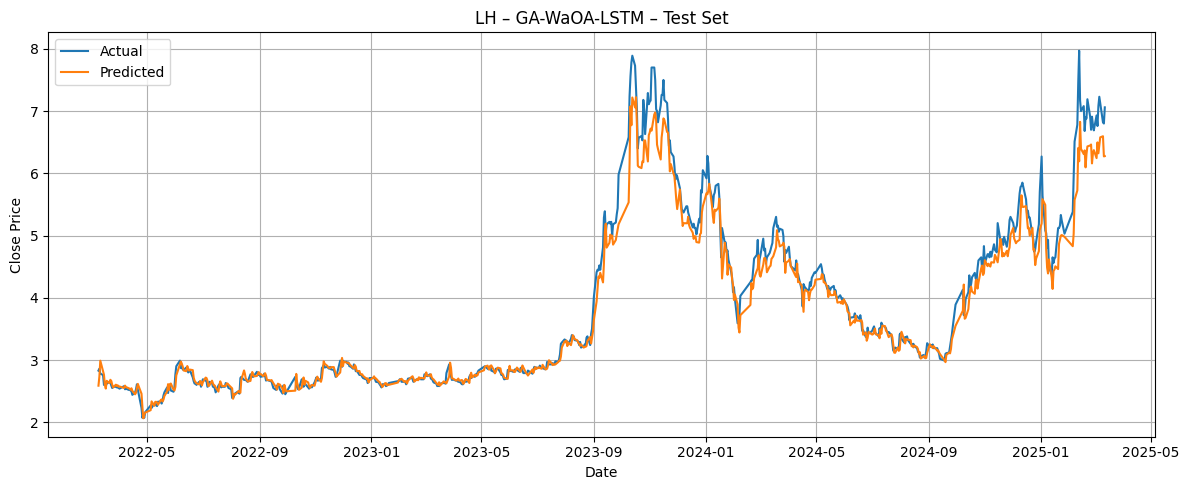

Saved figure: /kaggle/working/figures/LH_GA-WaOA-LSTM_prediction_full.png


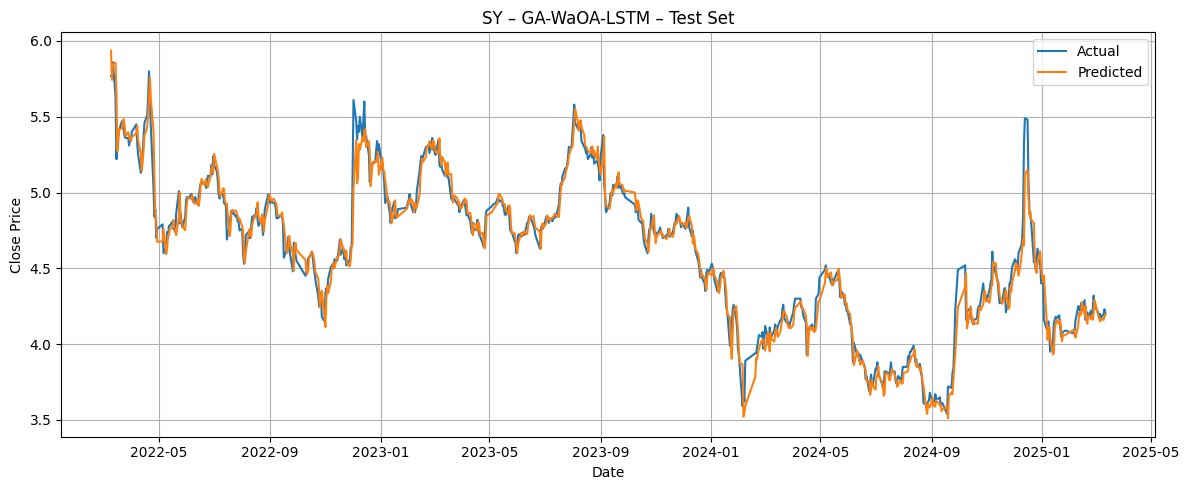

Saved figure: /kaggle/working/figures/SY_GA-WaOA-LSTM_prediction_full.png


In [41]:
for (stock_name, model_name), output in all_predictions.items():
    test_dates = prepared[stock_name]["test_dates"]

    plt.figure(figsize=(12, 5))
    plt.plot(test_dates, output["y_test_raw"], label="Actual")
    plt.plot(test_dates, output["pred_test_raw"], label="Predicted")
    plt.title(f"{stock_name} – {model_name} – Test Set")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    safe_model_name = model_name.replace("–", "-").replace(" ", "_")
    fig_path = FIGURE_DIR / f"{stock_name}_{safe_model_name}_prediction_{EXPERIMENT_MODE}.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {fig_path}")

## Final summary

In [40]:
best_rows = results_df.loc[results_df.groupby("Stock")["Test_RMSE"].idxmin()]
display(best_rows)

for _, row in best_rows.iterrows():
    print("=" * 65)
    print(f"Best enabled model for {row['Stock']}: {row['Model']}")
    print(f"Test MAE : {row['Test_MAE']:.6f}")
    print(f"Test MAPE: {row['Test_MAPE']:.4f}%")
    print(f"Test RMSE: {row['Test_RMSE']:.6f}")
    print(f"Test R²  : {row['Test_R2']:.6f}")
    print(f"Best epoch: {int(row['best_epoch'])}")
    print("Hyperparameters:")
    print(f"  units        : {int(row['units'])}")
    print(f"  dropout      : {row['dropout']:.6f}")
    print(f"  batch_size   : {int(row['batch_size'])}")
    print(f"  learning_rate: {row['learning_rate']:.8f}")

,Stock,Model,Train_MAE,Train_MAPE,Train_RMSE,Train_R2,Test_MAE,Test_MAPE,Test_RMSE,Test_R2,best_epoch,optimization_score,units,dropout,batch_size,learning_rate,log10_learning_rate
1,LH,GA-WaOA-LSTM,0.108236,2.554875,0.170078,0.991968,0.112524,2.603259,0.189995,0.981312,11,0.008538,301,0.081445,36,0.008549,-2.068095
2,SY,GA-WaOA-LSTM,0.145884,2.024495,0.227842,0.978367,0.069377,1.508137,0.101767,0.956089,25,0.012476,344,0.103841,63,0.010000,-2.000000
0,VV,GA-WaOA-LSTM,0.451355,7.787397,0.582807,0.878261,0.174854,5.922287,0.203377,0.742520,13,0.010027,396,0.128432,18,0.008950,-2.048185


Best enabled model for LH: GA-WaOA-LSTM
Test MAE : 0.112524
Test MAPE: 2.6033%
Test RMSE: 0.189995
Test R²  : 0.981312
Best epoch: 11
Hyperparameters:
  units        : 301
  dropout      : 0.081445
  batch_size   : 36
  learning_rate: 0.00854880
Best enabled model for SY: GA-WaOA-LSTM
Test MAE : 0.069377
Test MAPE: 1.5081%
Test RMSE: 0.101767
Test R²  : 0.956089
Best epoch: 25
Hyperparameters:
  units        : 344
  dropout      : 0.103841
  batch_size   : 63
  learning_rate: 0.01000000
Best enabled model for VV: GA-WaOA-LSTM
Test MAE : 0.174854
Test MAPE: 5.9223%
Test RMSE: 0.203377
Test R²  : 0.742520
Best epoch: 13
Hyperparameters:
  units        : 396
  dropout      : 0.128432
  batch_size   : 18
  learning_rate: 0.00894984
